In [1]:
from hcipy import *

#from astropy.modeling import models, fitting

import pynpoint

import pandas as pd
import importlib
import functions
importlib.reload(functions)
from functions import *

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import glob
import tifffile as tiff
#import seaborn as sns


from pathlib import Path
root_dir = Path(".")
print(root_dir)

import applefy
importlib.reload(applefy)
from applefy import *

importlib.reload(applefy.detections.contrast)
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, \
    fpf_2_gaussian_sigma, LaplaceBootstrapTest

from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.positions import center_subpixel


/home/aosimul/torch-test/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.


## Training

In [ ]:
img = tiff.imread('/home/aosimul/noah/data/ghost_images/phase_screens/tiff_stg1/21.82_2026-06-10T13-54-47.943_0.tif')
img_array = np.array(img)
plt.imshow(np.log10( zoom_to_peak(img[0], 20))) 
plt.colorbar(label = 'log intensity')

In [ ]:
np.unravel_index(np.argmax(img[0], axis=None), img[0].shape)


In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens/tiff_stg1/'
frames = []
output_gif = f'{folder}animation.gif'

center = (101,93)
radius = 80

winds = [0.91575148, 1.03320503, 0.82179083, 1.17081484, 0.95867449]
randomState = np.random.RandomState(42) 
overlay = None

for i, windspeed in enumerate(windspeeds):

    tiff_files = tiff.imread(f'{folder}{windspeed}*.tif')[:15]

    wind = np.asarray(
        list(randomState.randint(25, 29, 9))
    ) * winds[i]

    mini = np.log10(tiff_files.min())
    maxi = np.log10(tiff_files.max())

    for j, file in enumerate(tiff_files):

        data = file[
            center[0]-radius:center[0]+radius+1,
            center[1]-radius:center[1]+radius+1
        ]

        # Log scale
        frame = np.log10(np.maximum(data, 1e-10))

        # Normalize to uint8
        frame -= mini
        frame /= maxi
        frame = (255 * frame).astype(np.uint8)

        img = Image.fromarray(frame).convert("RGB")

        # Build overlay once using the size of the first frame
        if j == 0:
            label = (
                f"Mean Windspeed = {windspeed}\n"
                f"{np.array2string(wind, 
                                   separator='\n', 
                                   formatter={'float_kind': lambda x: f'{x:.2f}'}
                                   )}"
            )
            overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
            draw = ImageDraw.Draw(overlay)
            draw.text(
                (5, 5),
                label,
                fill=(255, 255, 255, 255)
            )

        img = Image.alpha_composite(
            img.convert("RGBA"),
            overlay
        )

        frames.append(np.asarray(img))

imageio.mimsave(output_gif, frames, duration=0.001)

print(f"Saved GIF: {output_gif}")




In [ ]:
psf_stg1 = np.concatenate([tiff.imread(f'{folder}{windspeed}*.tif')[:7500] for windspeed in windspeeds])
np.save(f'results/datasets/psf_stg1_psf.npy', psf_stg1)

In [ ]:
psf_stg1     = np.load('results/datasets/psf_stg1_psf.npy')

plt.imshow(np.log10(np.mean(psf_stg1[:, 73:133, 64:124], axis = 0)))
plt.colorbar()
plt.title(f'Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min \nFWHM = {calculate_fwhm(np.mean(psf_stg1, axis = 0)):.2f}pix')
plt.show()

plt.figure(figsize=(20,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(psf_stg1[7500*(i-1):7500*i, 73:133, 64:124], axis = 0)), vmin = 2)
    plt.colorbar(fraction = 0.04)
    plt.title(f'Mean PSF over {7500*0.005:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm(np.mean(psf_stg1[7500*(i-1):7500*i, :, :], axis = 0)):.2f}pix')
plt.show()

plt.figure(figsize=(20,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((psf_stg1[7500*i -1, 73:133, 64:124])), vmin = 2)
    plt.colorbar(fraction = 0.04)
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((psf_stg1[7500*i -1, :, :])):.2f}pix')
plt.show()

## Load and View Images

### Download

In [6]:
windspeeds = [21.82, 24.32,25.46, 27.44, 31.09]


In [7]:
# DOWNLOAD TIFF

folder      = '/home/aosimul/noah/data/ghost_images/phase_screens/tiff_4ms/'
sc_img      = np.concatenate([tiff.imread(sorted(glob.glob(f'{folder}{windspeed}_stg2_int*.tif')))[:9375] for windspeed in windspeeds])
sc_img_int  = sc_img.astype(np.float32) / 65535
sc_img      = np.concatenate([tiff.imread(sorted(glob.glob(f'{folder}{windspeed}_stg2_pred*.tif')))[:9375] for windspeed in windspeeds])
sc_img_pred = sc_img.astype(np.float32) / 65535

#center - assume centre is consistent throughout (i checked before)
coords_max1 = (np.unravel_index(np.argmax(sc_img_int[0], axis=None), sc_img_int[0].shape))
coords_max2 = (np.unravel_index(np.argmax(sc_img_pred[0], axis=None), sc_img_pred[0].shape))
coords_max  = max(coords_max1, coords_max2)
Large_rad   = min(coords_max)
sc_img_pred = sc_img_pred[:, coords_max[0]-Large_rad:coords_max[0]+Large_rad+1, coords_max[1]-Large_rad:coords_max[1]+Large_rad+1]
sc_img_int  = sc_img_int[:, coords_max[0]-Large_rad:coords_max[0]+Large_rad+1, coords_max[1]-Large_rad:coords_max[1]+Large_rad+1]

print(sc_img_pred.shape, sc_img_int.shape)
np.save(f'/home/aosimul/noah/data/ghost_images/4ms/stg2_int.npy', sc_img_int)
np.save(f'/home/aosimul/noah/data/ghost_images/4ms/stg2_pred.npy', sc_img_pred)

(46875, 187, 187) (46875, 187, 187)


In [34]:
coords = np.array([
    np.unravel_index(np.argmax(frame), frame.shape)
    for frame in sc_img_int
])

mean_coord = coords.mean(axis=0)

print(mean_coord)  # (y_mean, x_mean)

coords = np.array([
    np.unravel_index(np.argmax(frame), frame.shape)
    for frame in sc_img_pred
])

mean_coord = coords.mean(axis=0)

print(mean_coord)  # (y_mean, x_mean)

[92.03163733 91.29998933]
[92.001024 92.693184]


### Load Saved Frames

In [2]:
# LOAD IMAGES
# 
##psf_stg1 = np.concatenate([tiff.imread(f'{folder}{windspeed}*.tif')[:7500] for windspeed in windspeeds])
#np.save(f'results/datasets/psf_stg1_psf.npy', psf_stg1)

frame_rate  = 1/400 #s
dit_science = 4e-3  #s
dit_psf     = 10    #s
pixel_size  = 0.005 #arcsec
LambdaD     = 4     #pixels
n_psf       = round(dit_psf/dit_science)
radius      = 20
sc_img_int  = np.load('/home/aosimul/noah/data/ghost_images/4ms/stg2_int.npy')
sc_img_pred = np.load('/home/aosimul/noah/data/ghost_images/4ms/stg2_pred.npy')
sc_img_int  = sc_img_int[:, ]
psf_int     = np.sum(sc_img_int[:n_psf],  axis = 0)
psf_int     = zoom_to_peak(psf_int, radius)
psf_pred    = np.sum(sc_img_pred[:n_psf], axis = 0)
psf_pred    = zoom_to_peak(psf_pred, radius)

In [4]:
# OPTIONAL: INCREASE INTEGRATION TIME
sc_img_int     = sc_img_int.reshape(int(sc_img_int.shape[0]/5), 5, *sc_img_int.shape[1:]).sum(axis=1)
sc_img_pred    = sc_img_pred.reshape(int(sc_img_pred.shape[0]/5), 5, *sc_img_pred.shape[1:]).sum(axis=1)
dit_science    = dit_science*5

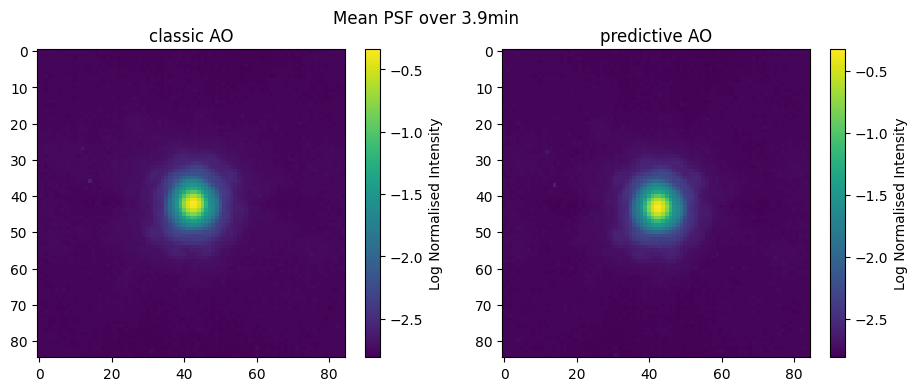

FWHM_x = 4.27 pix
FWHM_y = 4.63 pix
Mean FWHM = 4.45 pix 

FWHM_x = 4.28 pix
FWHM_y = 4.63 pix
Mean FWHM = 4.46 pix 

FWHM_x = 4.29 pix
FWHM_y = 4.64 pix
Mean FWHM = 4.46 pix 

FWHM_x = 4.30 pix
FWHM_y = 4.65 pix
Mean FWHM = 4.48 pix 

FWHM_x = 4.33 pix
FWHM_y = 4.68 pix
Mean FWHM = 4.50 pix 



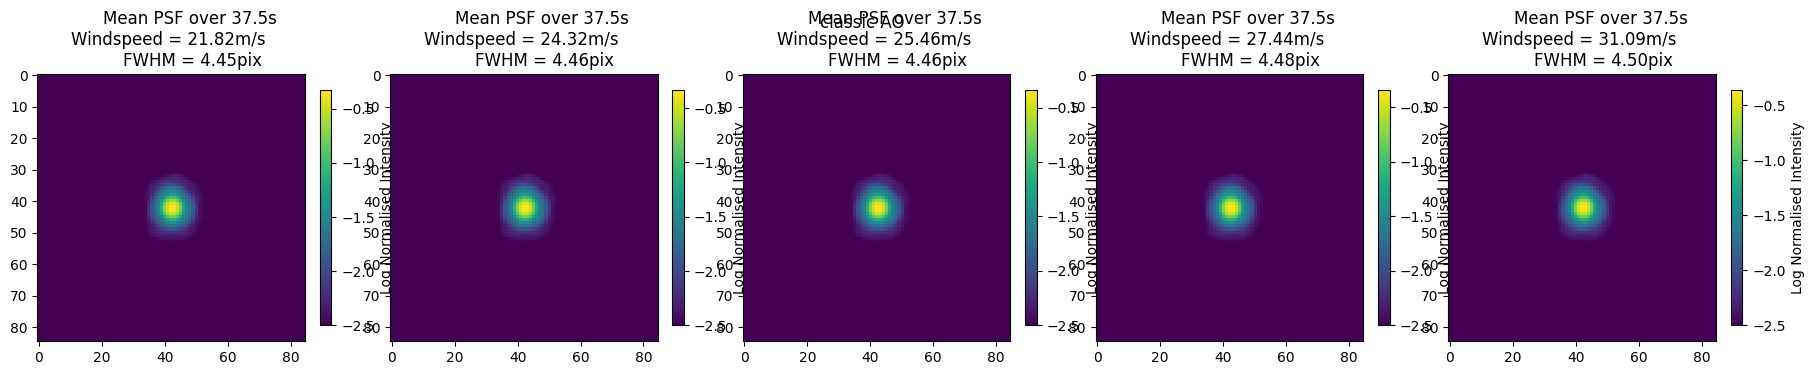

FWHM_x = 4.26 pix
FWHM_y = 4.60 pix
Mean FWHM = 4.43 pix 

FWHM_x = 4.27 pix
FWHM_y = 4.60 pix
Mean FWHM = 4.43 pix 

FWHM_x = 4.27 pix
FWHM_y = 4.61 pix
Mean FWHM = 4.44 pix 

FWHM_x = 4.28 pix
FWHM_y = 4.61 pix
Mean FWHM = 4.45 pix 

FWHM_x = 4.31 pix
FWHM_y = 4.63 pix
Mean FWHM = 4.47 pix 



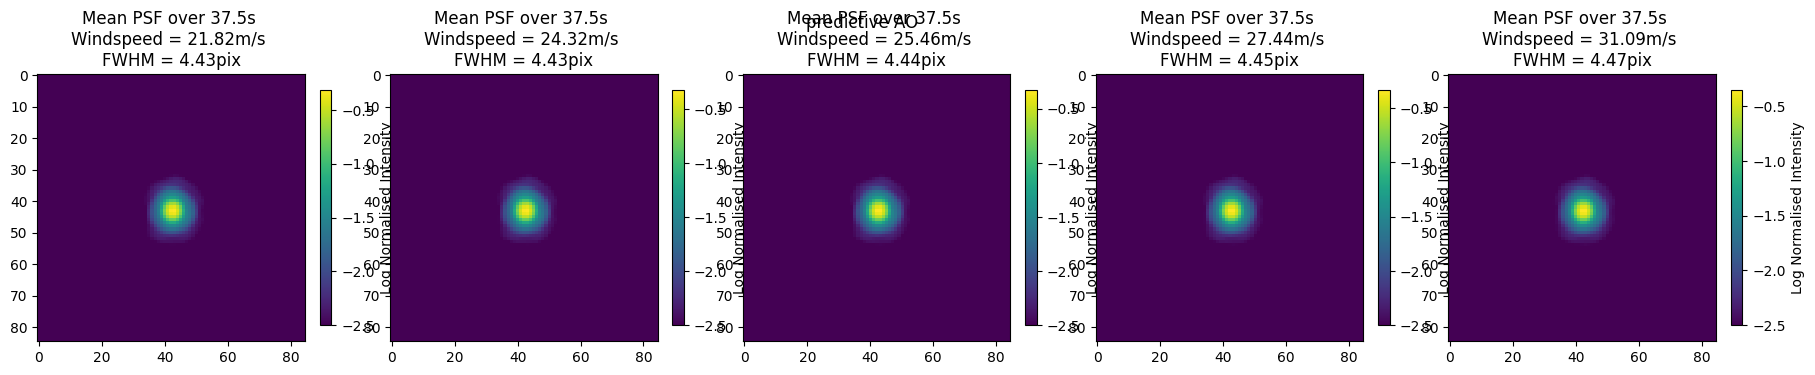

FWHM_x = 4.23 pix
FWHM_y = 4.65 pix
Mean FWHM = 4.44 pix 

FWHM_x = 4.28 pix
FWHM_y = 4.56 pix
Mean FWHM = 4.42 pix 

FWHM_x = 4.25 pix
FWHM_y = 4.69 pix
Mean FWHM = 4.47 pix 

FWHM_x = 4.23 pix
FWHM_y = 4.63 pix
Mean FWHM = 4.43 pix 

FWHM_x = 4.35 pix
FWHM_y = 4.52 pix
Mean FWHM = 4.43 pix 



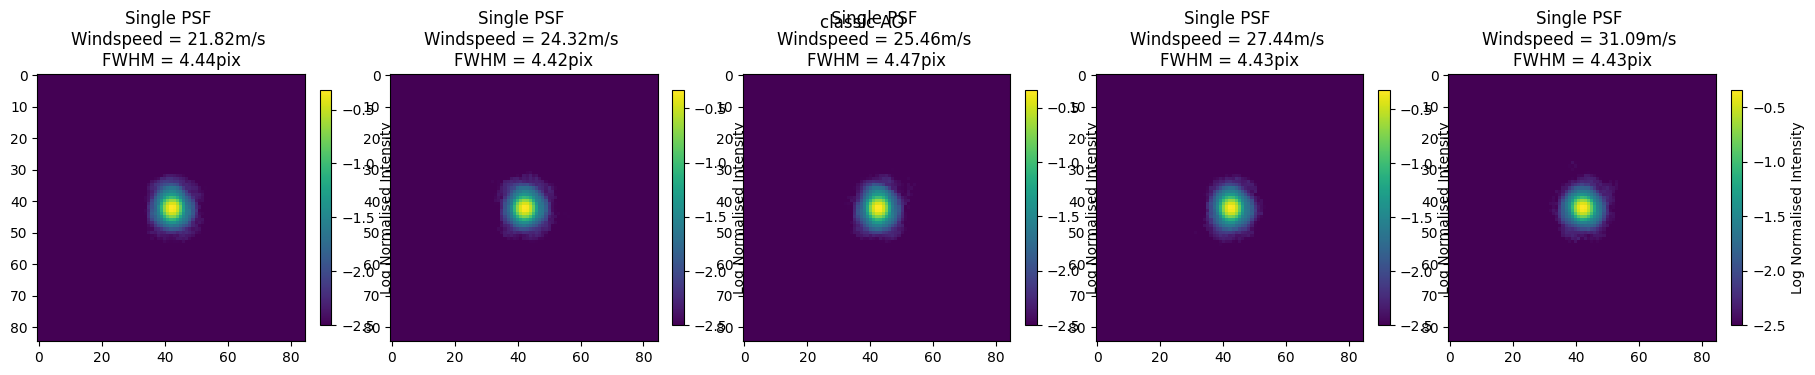

FWHM_x = 4.67 pix
FWHM_y = 4.30 pix
Mean FWHM = 4.49 pix 

FWHM_x = 4.56 pix
FWHM_y = 4.25 pix
Mean FWHM = 4.40 pix 

FWHM_x = 4.25 pix
FWHM_y = 4.60 pix
Mean FWHM = 4.42 pix 

FWHM_x = 4.26 pix
FWHM_y = 4.54 pix
Mean FWHM = 4.40 pix 

FWHM_x = 4.31 pix
FWHM_y = 4.58 pix
Mean FWHM = 4.45 pix 



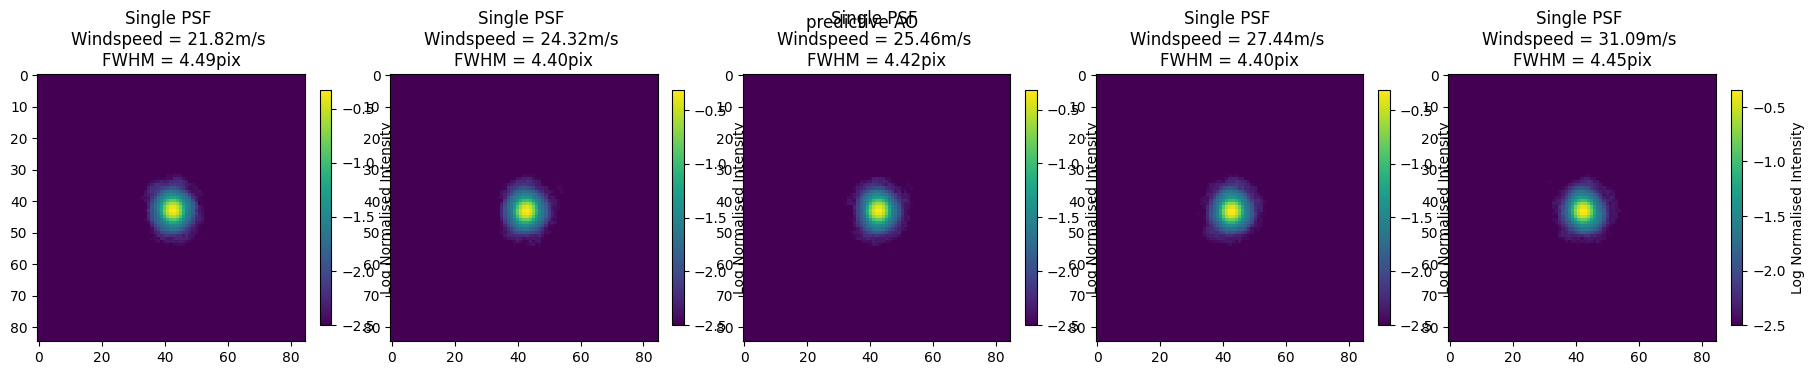

In [ ]:
psf_stg1     = sc_img_int
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(np.mean(psf_stg1[:, 50:135, 50:135], axis = 0)))
plt.title('classic AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(np.mean(sc_img_pred[:, 50:135, 50:135], axis = 0)))
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.title('predictive AO')
plt.suptitle(f'        Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min')
plt.show()

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(np.mean(psf_stg1[:, 50:135, 50:135], axis = 0)))
plt.title('classic AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(np.mean(sc_img_pred[:, 50:135, 50:135], axis = 0)))
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.title('predictive AO')
plt.suptitle(f'        Mean PSF over {np.shape(psf_stg1)[0]*0.005/60:.1f}min')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(psf_stg1[9375*(i-1):9375*i,  50:135, 50:135], axis = 0)), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'        Mean PSF over {9375*0.004:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \n        FWHM = {calculate_fwhm(np.mean(psf_stg1[9375*(i-1):9375*i, :, :], axis = 0)):.2f}pix')
plt.suptitle('classic AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10(np.mean(sc_img_pred[9375*(i-1):9375*i, 50:135, 50:135], axis = 0)), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Mean PSF over {9375*0.004:.1f}s \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm(np.mean(sc_img_pred[9375*(i-1):9375*i, :, :], axis = 0)):.2f}pix')
plt.suptitle('predictive AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((psf_stg1[9375*i -1, 50:135, 50:135])), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((psf_stg1[9375*i -1, :, :])):.2f}pix')
plt.suptitle('classic AO')
plt.show()

plt.figure(figsize=(22,4))
for i in range(1,6):
    plt.subplot(1,5,i)
    plt.imshow(np.log10((sc_img_pred[9375*i -1, 50:135, 50:135])), vmin = -2.5)
    plt.colorbar(fraction = 0.04, label = 'Log Normalised Intensity')
    plt.title(f'Single PSF \nWindspeed = {windspeeds[i-1]}m/s \nFWHM = {calculate_fwhm((sc_img_pred[9375*i -1, :, :])):.2f}pix')
plt.suptitle('predictive AO')
plt.show()

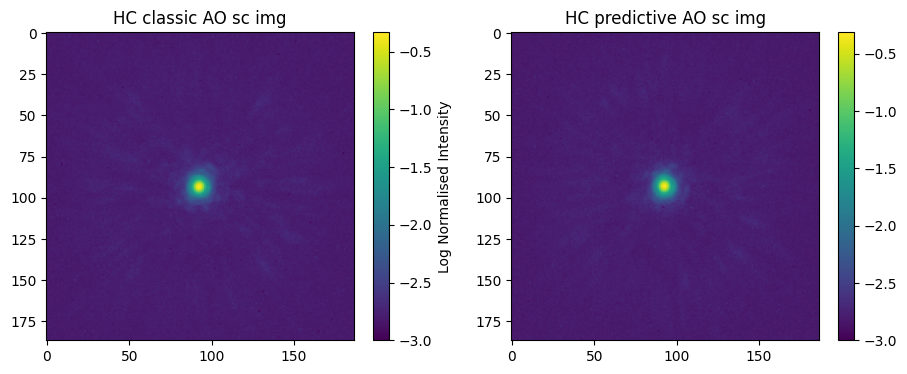

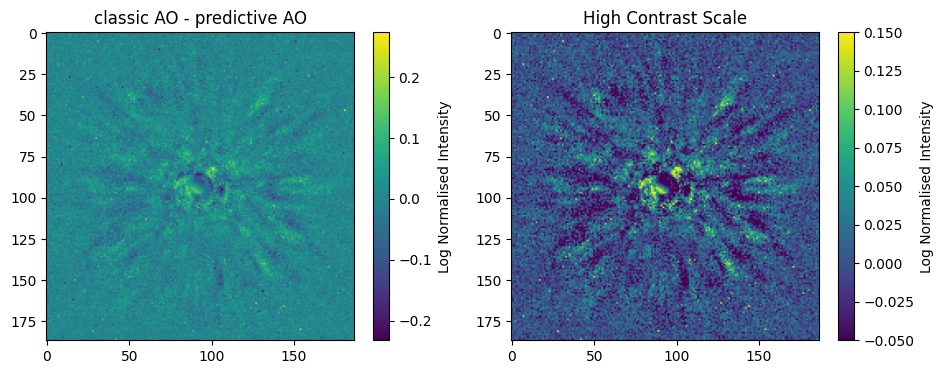

In [10]:
# VIEW

# plt.figure(figsize=(11,4))
# plt.subplot(1,2,1)
# plt.imshow(np.log10(psf_int))
# plt.title('classic AO psf')
# plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
# plt.subplot(1,2,2)
# plt.imshow(np.log10(psf_pred))
# plt.title('predictive AO psf')
# plt.colorbar(fraction =0.04)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(sc_img_int[0]), vmin = -3)
plt.title('HC classic AO sc img')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(sc_img_pred[0]), vmin = -3)
plt.title('HC predictive AO sc img')
plt.colorbar(fraction =0.04)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(np.log10(sc_img_int[0]) - np.log10(sc_img_pred[0, :, :]))
plt.title('classic AO - predictive AO')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')
plt.subplot(1,2,2)
plt.imshow(np.log10(sc_img_int[0]) - np.log10(sc_img_pred[0, :, :]), vmax = 0.15, vmin = -0.05)
plt.title('High Contrast Scale')
plt.colorbar(fraction =0.04, label = 'Log Normalised Intensity')


## Generate Comtrast Curves

### Create Fake Planets

In [ ]:
# CREATE DATASETS
datasets = {
    "int": {
        "psf"           : psf_int,
        "sci_img"       : sc_img_int2,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science2,     #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "sci_img"       : sc_img_pred2,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science2,  
    },
}

algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

curves = {}

#FILL
#-----------
# fake planet brightness
flux_ratio_mag          = 16
num_fake_planets        = 3
components              = [5, 10, 20, 50, 75, 100] 
scaling_factor          = 1.0  # A factor to account e.g. for ND filters
angles                  = np.linspace(0, 30, np.shape(sc_img_int)[0])   #parang[::10]
angles                  = np.deg2rad(angles)
flux_ratio              = mag2flux_ratio(flux_ratio_mag)
name                    = 'GHOST_no_coro'
separation              = 1
max_separation          = 0.8                                           #in fraction of total image radius
approx_svd_trunc        = round(np.shape(sc_img_int)[0] / 3)
device                  = 'cuda'                                        #'cpu'
#-----------

for dataset_name, dataset in datasets.items():
    for algo_name, alg in algorithms.items():

        path = f"results/contrast_curves/{name}_{dataset_name}_{algo_name}"
        if not os.path.exists(path):
            os.makedirs(path)
            
        contrast_instance = Contrast(
            science_sequence    =dataset["sci_img"],
            psf_template        =dataset["psf"],
            parang_rad          =angles,
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            scaling_factor      =scaling_factor, # A factor to account e.g. for ND filters
            checkpoint_dir      =root_dir / Path(path)
            )
        seps =  None if separation == None else np.arange(0, round(center_subpixel(dataset["sci_img"][0])[0] * max_separation), dataset["fwhm"]* separation)[1:]
        contrast_instance = fake_planet_experiment(contrast_instance, flux_ratio, num_fake_planets, components, version = alg,
        separations = seps, 
        approx_svd = approx_svd_trunc if approx_svd_trunc else -1,
        device= device)
        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')

    # save the contrast curves in a single dataframe
    (curve, err) = curves[(dataset_name, "PCAD")]
    (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

    curves[(dataset_name, "merged")] = (
        pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
        pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
    )

In [4]:
# GPU BULLSHIT

import gc
import torch
import psutil, os

print("Allocated:",
      torch.cuda.memory_allocated()/1024**3, "GB")

print("Reserved:",
      torch.cuda.memory_reserved()/1024**3, "GB")



process = psutil.Process(os.getpid())

print("CPU RAM:",
    process.memory_info().rss / 1024**3,
    "GB"
)

total = 0

for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj):
            total += obj.numel() * obj.element_size()
    except Exception:
        pass

print(total / 1024**3, "GB in live tensors")


Allocated: 0.0 GB
Reserved: 0.0 GB
CPU RAM: 12.931629180908203 GB
0.0 GB in live tensors


/home/aosimul/torch-test/lib64/python3.12/site-packages/torch/__init__.py:1172: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


### From Folders

In [ ]:
# CREATE CURVES FROM CHECKPOINT DIR

datasets = {
    "int": {
        "psf"           : psf_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,            #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,      #s of integration time
        "dit_science"   : dit_science,  
    },
    
}


algorithms = {
    "PCAD": "PCAD",
    "CADI": "CADI",
}

curves = {}

#FILL
#-----------
name                    = 'GHOST_no_coro52'
#-----------


for dataset_name, dataset in datasets.items():
    for algo_name, device in algorithms.items():

        path = f"results/contrast_curves/{name}_{dataset_name}_{algo_name}"
        
        contrast_instance = Contrast.create_from_checkpoint_dir(
            psf_template        =dataset["psf"],
            psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
            dit_psf_template    =dataset["dit_psf"], 
            dit_science         =dataset["dit_science"],  # integration time
            checkpoint_dir      =root_dir / Path(path)
            )

        curves[(dataset_name, algo_name)] = compute_contrast_curves(contrast_instance, dataset["fwhm"], pixel_scale=pixel_size,  photometry = 'AS', test = 't-test')


    # save the contrast curves in a single dataframe
    (curve, err) = curves[(dataset_name, "PCAD")]
    (curve_cadi, err_cadi) = curves[(dataset_name, "CADI")]

    curves[(dataset_name, "merged")] = (
        pd.merge(curve, curve_cadi, left_index= True, right_index=True, how="inner"),
        pd.merge(err, err_cadi, left_index= True, right_index=True, how="inner")
    )

curves52 = curves.copy()

FWHM_x = 4.27 pix
FWHM_y = 4.62 pix
Mean FWHM = 4.45 pix 

FWHM_x = 4.26 pix
FWHM_y = 4.60 pix
Mean FWHM = 4.43 pix 

Computing contrast curve for _PCA_005_components


100%|██████████| 16/16 [00:11<00:00,  1.39it/s]


Computing contrast curve for _PCA_010_components


100%|██████████| 16/16 [00:12<00:00,  1.32it/s]


Computing contrast curve for _PCA_020_components


...

100%|██████████| 16/16 [00:11<00:00,  1.36it/s]


Computing contrast curve for _PCA_100_components


100%|██████████| 16/16 [00:12<00:00,  1.28it/s]


Computing contrast curve for cADI


100%|██████████| 16/16 [00:12<00:00,  1.31it/s]


/home/aosimul/noah/functions.py:543: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
/home/aosimul/noah/functions.py:543: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


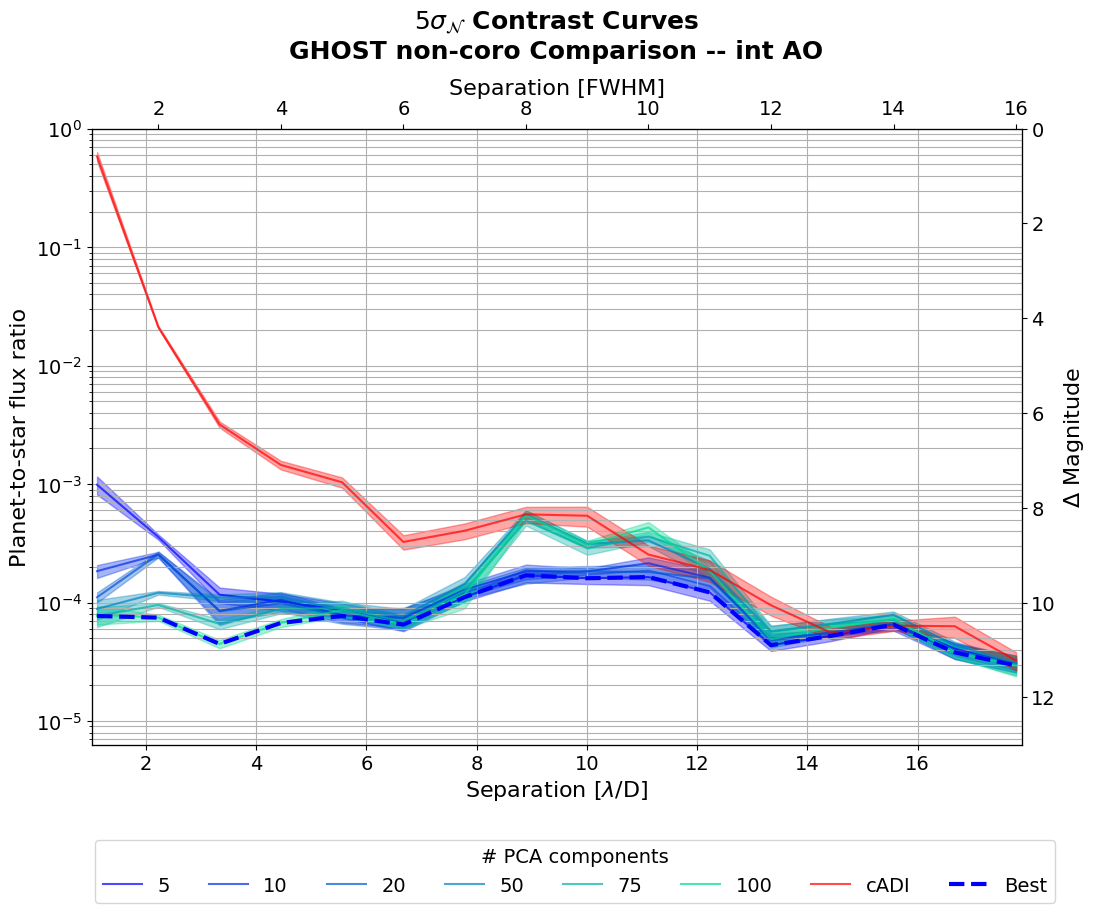

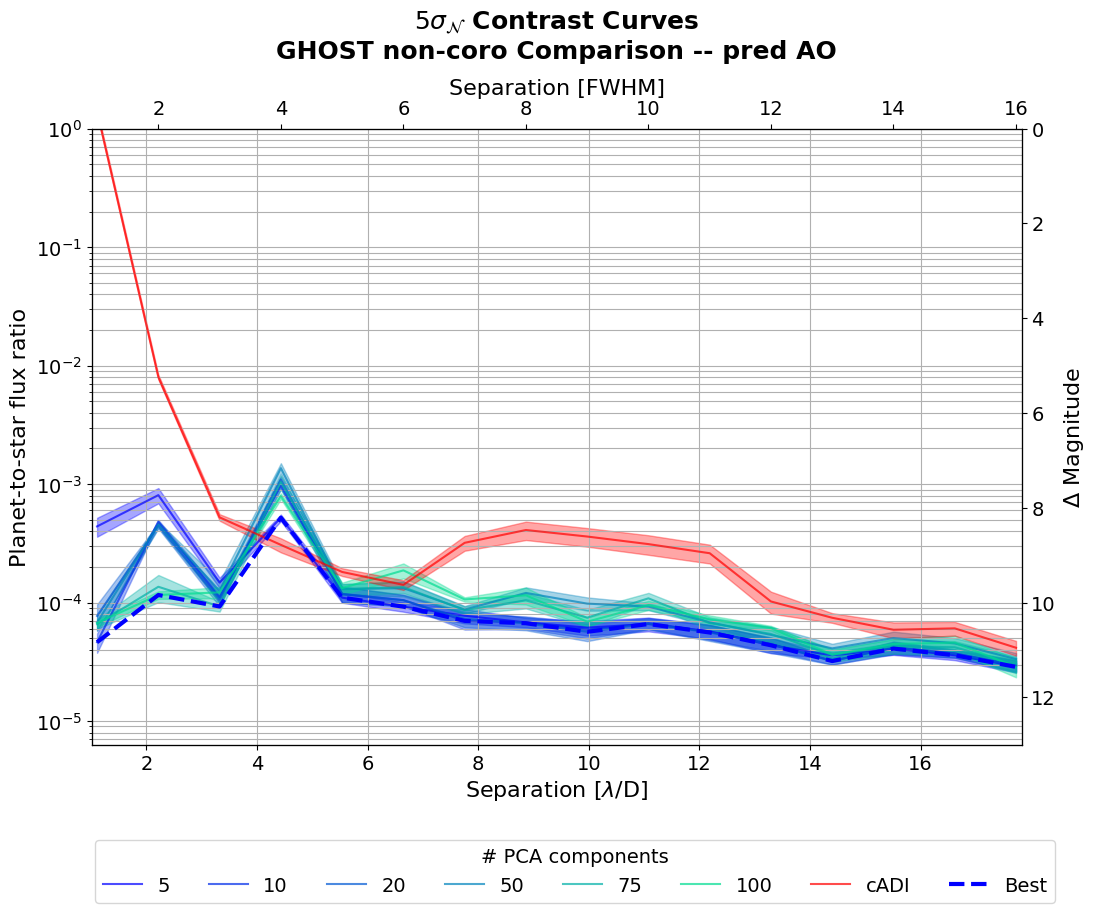

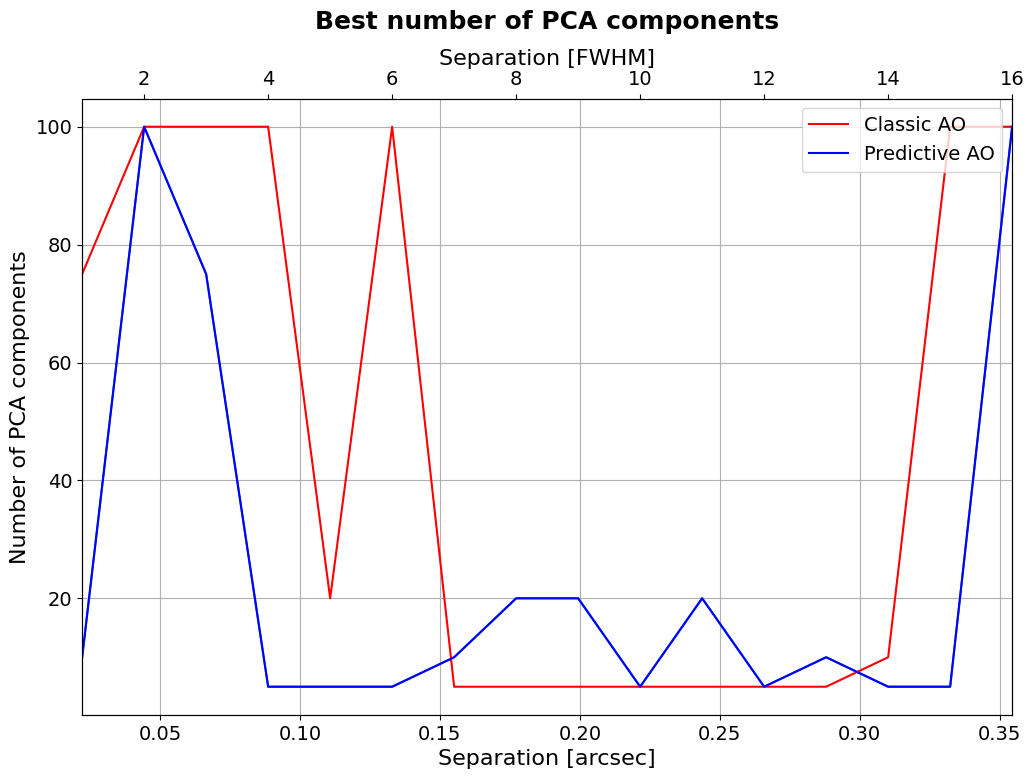

In [7]:
# MAKE PLOTS
rangey = (13, 0)
name = 'GHOST non-coro Comparison'
components              = [5, 10, 20, 50, 75, 100] 

for dataset_name, dataset in datasets.items():
    contrast, err = curves5[(dataset_name, "merged")]
    plot_contrast_curves(contrast, err, rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name} AO"), x_axis = (1/LambdaD/pixel_size), x_axis_label= r"Separation [$\lambda$/D]")
    plt.savefig(f'{dataset_name}_{name}.png')

plot_best_PCA_number([curves5[("int", "PCAD")][0], curves5[("pred", "PCAD")][0]], components, ['Classic AO', 'Predictive AO'])
plt.savefig(f'PCA_{name}.png')

In [ ]:
folder = '/home/aosimul/noah/results/contrast_curves/test2'
create_pca_gif(
    folder,
    components,
    output_gif="pred_newlyot_safe.gif",
    duration=0.5,
)

/home/aosimul/noah/functions.py:806: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [color_map(i) for i in np.linspace(0, 1, len(delta.columns))]
/home/aosimul/noah/functions.py:806: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = [color_map(i) for i in np.linspace(0, 1, len(delta.columns))]


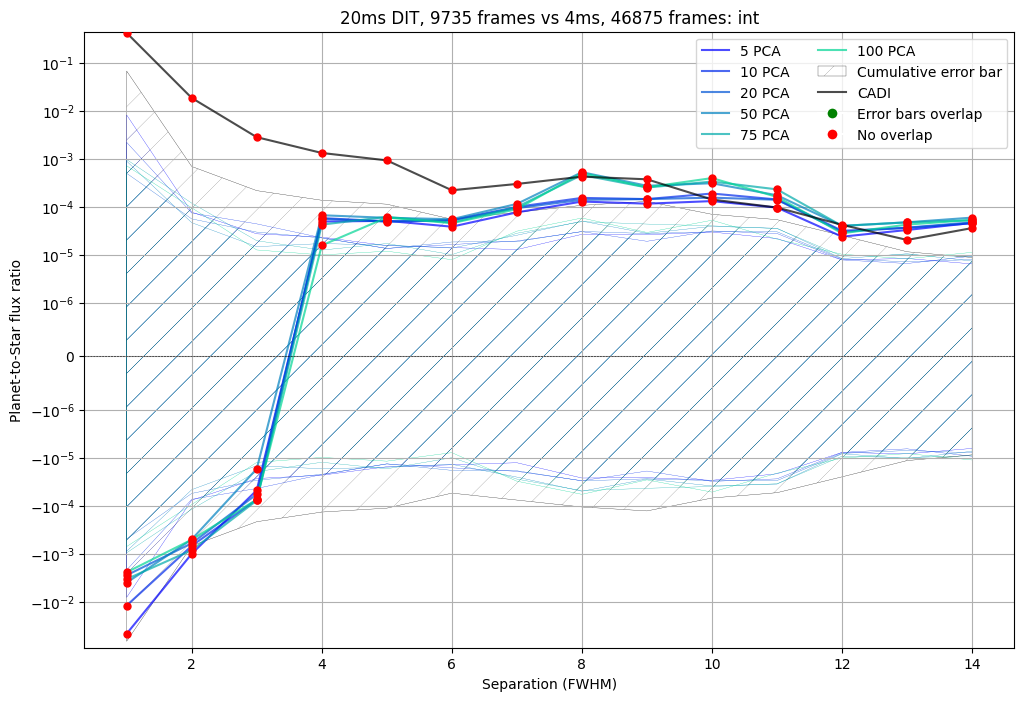

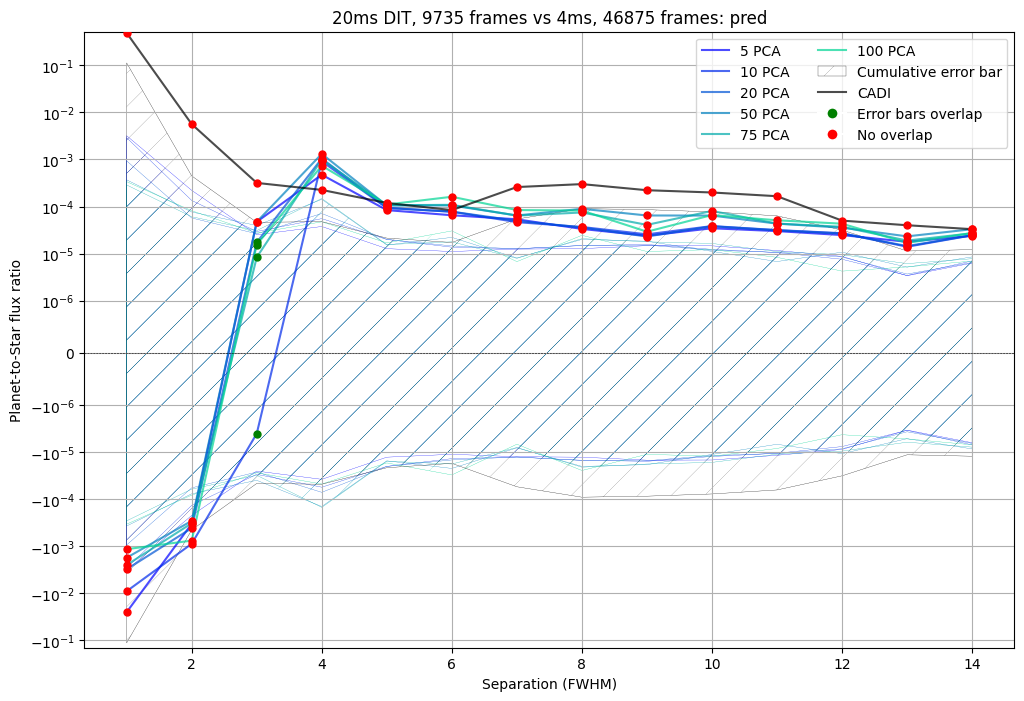

In [101]:
# MAKE PLOTS
rangey = (13, 0)
name = 'GHOST non-coro Comparison'
components              = [5, 10, 20, 50, 75, 100] 

for dataset_name, dataset in datasets.items():
    contrast1, err1 = curves5[(dataset_name, "merged")]
    contrast2, err2 = curves[(dataset_name, "merged")]


    comparison(
        contrast1,
        err1,
        contrast2,
        err2,
        title=f"20ms DIT, 9735 frames vs 4ms, {9375*5} frames: {dataset_name}",
        x_axis=(1/LambdaD/pixel_size),
        cmap = 'winter'
    )